## Validación de la ley de Zipf


¿Por qué aparece?

No hay una única explicación, pero hay teorías importantes.

1. Principio de mínimo esfuerzo (Zipf)

Los sistemas tienden a equilibrar:

esfuerzo del emisor

esfuerzo del receptor

En lenguaje:

pocas palabras muy frecuentes → eficiencia

muchas raras → expresividad

...

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
from collections import Counter

ModuleNotFoundError: No module named 'numpy'

In [ ]:
# Leemos el archivo con el corpus de texto
df = pd.read_csv("https://raw.githubusercontent.com/Jorgeprevi/ML_bootcamp_2026/refs/heads/main/regresion_lineal/textos.csv")
df.head()

In [ ]:
# Quitamos los signos de puntuación de la columna de texto
def remove_punctuations(input_col):
    """Función para eliminar los signos de puntuación de una columna de texto"""
    table = str.maketrans('','',string.punctuation)
    return input_col.translate(table)

df['text'] = df['text'].apply(remove_punctuations)

In [ ]:
# creamos una lista con todas las palabras del corpus de texto (minúscula)
def build_corpus(text_col):
    """construye un corpus de texto a partir de una columna de texto"""
    corpus = ""
    for sent in text_col:
        corpus += sent
    return corpus

corpus = build_corpus(df['text'])
corpus = corpus.lower()

corpus[:1000]

In [ ]:
# Creamos una lista con todas las palabras del corpus de texto
corpus = corpus.split()
print(corpus[:50])

In [ ]:
def zipf_plots(words, top_n=30, min_count=1, drop_top_k=0, fit_max_rank=None):
    """
    Genera 2 figuras:
      (1) Barplot con las top-N palabras (apariciones en eje Y).
      (2) Zipf plot (freq vs rank) en log-log + curva ajustada (OLS en log10).
    """
    # 1) Contar y ordenar
    counts = Counter(words)
    items = sorted(counts.items(), key=lambda x: x[1], reverse=True)

    # Filtrado por frecuencia mínima
    if min_count > 1:
        items = [(w, c) for (w, c) in items if c >= min_count]

    if len(items) < 5:
        raise ValueError("Muy pocos elementos tras el filtrado; reduce min_count o revisa datos.")

    # ---- FIGURA 1: Barplot Top-N ----
    top_n = min(top_n, len(items))
    top_words = [w for (w, _) in items[:top_n]]
    top_counts = [c for (_, c) in items[:top_n]]

    plt.figure()
    plt.bar(range(top_n), top_counts)
    plt.xticks(range(top_n), top_words, rotation=60, ha="right")
    plt.ylabel("Apariciones")
    plt.title(f"Top {top_n} palabras más frecuentes")
    plt.grid(True, axis="y", linestyle=":")
    plt.tight_layout()
    plt.show()

    # ---- Preparar arrays rank/freq para Zipf ----
    freqs = np.array([c for (_, c) in items], dtype=float)
    ranks = np.arange(1, len(freqs) + 1, dtype=float)

    # Opcional: quitar top-k del análisis Zipf
    if drop_top_k > 0:
        freqs = freqs[drop_top_k:]
        ranks = np.arange(1, len(freqs) + 1, dtype=float)

    # Tramo para el fit
    if fit_max_rank is not None:
        m = ranks <= float(fit_max_rank)
        r_fit = ranks[m]
        f_fit = freqs[m]
    else:
        r_fit = ranks
        f_fit = freqs

    x = np.log10(r_fit)
    y = np.log10(f_fit)

    # OLS en logspace: y = a + b x  => s = -b
    b, a = np.polyfit(x, y, 1)
    s_hat = -b
    C_hat = 10 ** a

    # R² en espacio log
    y_pred = a + b * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # ---- FIGURA 2: Zipf ----
    plt.figure()
    plt.loglog(ranks, freqs, marker=".", linestyle="none")
    f_model = C_hat * (ranks ** (-s_hat))
    plt.loglog(ranks, f_model, linestyle="--")
    plt.xlabel("Rank")
    plt.ylabel("Frecuencia")
    plt.title(f"Zipf: s≈{s_hat:.3f}  (fit log10, R²≈{r2:.3f})")
    plt.grid(True, which="both", linestyle=":")
    plt.show()

    return {
        "s_hat": float(s_hat),
        "C_hat": float(C_hat),
        "r2_logspace": float(r2),
        "n_types": int(len(freqs)),
        "n_tokens": int(sum(counts.values())),
    }

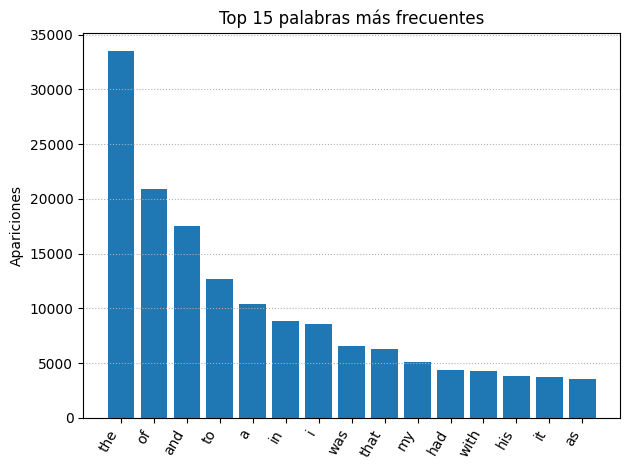

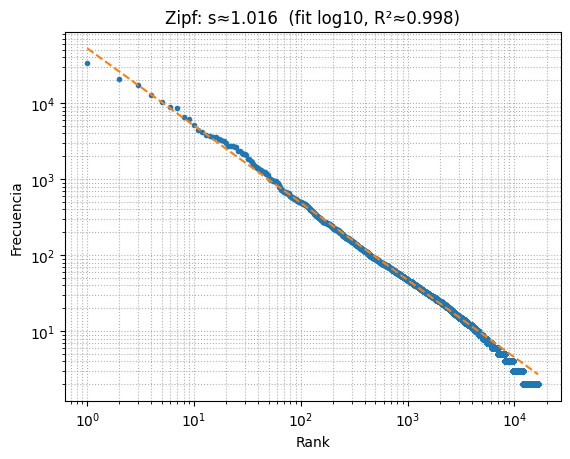

In [25]:
res = zipf_plots(corpus, top_n=15, min_count=2, drop_top_k=0, fit_max_rank=5000)